# Análisis Exploratorio de Datos (EDA) con NumPy y Pandas sobre World Happiness
Aplicar el ciclo completo de exploración de datos: reconocimiento inicial, limpieza (cleaning), análisis descriptivo y visualización, usando un dataset real de Kaggle


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [76]:
# Lectura de data set e inicialización de cada uno para exploración respecto a su año
first_year=2015
last_year=2019

dfs_initial = []

for year in range(2015, 2020):
    df = pd.read_csv(f"./data/{year}.csv")
    df["year"] = year
    dfs_initial.append(df)

In [77]:
dfs_initial[0].head() # Data frame del año 2015

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,year
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015


In [78]:
dfs_initial[1].head() # Data frame del año 2016

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,year
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939,2016
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463,2016
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137,2016
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465,2016
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596,2016


In [79]:
dfs_initial[2].head() # Data frame del año 2017

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual,year
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,2017
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,2017
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,2017
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,2017
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,2017


In [80]:
dfs_initial[3].head() # Data frame del año 2018

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,year
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393,2018
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340,2018
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408,2018
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138,2018
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357,2018


In [81]:
dfs_initial[4].head() # Data frame del año 2019

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,year
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,2019
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,2019
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,2019
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,2019
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,2019


Los cinco archivos usan esquemas distintos: nombres diferentes para la misma variable como: `Country o region, GDP per capital, Perceptions of corruption, Freedom, family`, las cuales afectan directamente el score de felicidad segun el data set; así mismo hay columnas que solo aparecen en algunos años como: `Whisker.low o Whisker.high`

In [82]:
# Concatenacion temporal de los dataframes
df_raw = pd.concat(dfs_initial, ignore_index=True)

print("shape:", df_raw.shape)
df_raw.info()

shape: (782, 31)
<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        470 non-null    str    
 1   Region                         315 non-null    str    
 2   Happiness Rank                 315 non-null    float64
 3   Happiness Score                315 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       315 non-null    float64
 6   Family                         470 non-null    float64
 7   Health (Life Expectancy)       315 non-null    float64
 8   Freedom                        470 non-null    float64
 9   Trust (Government Corruption)  315 non-null    float64
 10  Generosity                     782 non-null    float64
 11  Dystopia Residual              315 non-null    float64
 12  year                           782 non-null 

En un primer momento hicimos una concatenación directa, pero pandas alinea por nombre de columna y el resultado fue una data frame con columnas repetidas pero con nombres distintos, saliendo una columna de **782 filas x 31 columnas** y casi todas incompletas. `Generosity` es la única con 782 valores no nulos, porque es la única columna que se llama igual en los cinco archivos. Esto generaba gran cantidad de valores nulos, por lo cual fue necesario estandarizarlas. 

### Estandarización y limpieza de Dataset 

Primero identificamos cuales serian las columnas a estandarizar, para ello analizamos el dataset encontrando que columnas como: `Family y Social Support, Trust (Government Corruption) y Perceptions of corruption` representaban lo mismo, así que se creo un diccionario con las columnas a renombrar por año.

In [83]:
RENAME_2015_2016 = {
    "Happiness Rank": "Overall rank",
    "Happiness Score": "Score",
    "Economy (GDP per Capita)": "GDP per Capita",
    "Family": "Social support",
    "Trust (Government Corruption)": "Perceptions of corruption",
}

RENAME_2017 = {
    "Happiness.Rank": "Overall rank",
    "Happiness.Score": "Score",
    "Economy..GDP.per.Capita.": "GDP per Capita",
    "Family": "Social support",
    "Health..Life.Expectancy.": "Health (Life Expectancy)",
    "Trust..Government.Corruption.": "Perceptions of corruption",
}

RENAME_2018_2019 = {
    "Country or region": "Country",
    "GDP per capita": "GDP per Capita",
    "Healthy life expectancy": "Health (Life Expectancy)",
    "Freedom to make life choices": "Freedom",
}

RENAME_BY_YEAR = {
    2015: RENAME_2015_2016,
    2016: RENAME_2015_2016,
    2017: RENAME_2017,
    2018: RENAME_2018_2019,
    2019: RENAME_2018_2019,
}

# rename() devuelve una copia, asi que dfs_initial queda intacto
dfs = []
for df in dfs_initial:
    year = df["year"].iloc[0]
    dfs.append(df.rename(columns=RENAME_BY_YEAR[year]))


#### Normalizar los nombres de país

`Region` solo existe en 2015 y 2016, así que la vamos a propagar cruzando por el nombre
del país. Pero antes hay que arreglar un detalle: varios países cambiaron de nombre entre
ediciones del reporte. Si cruzamos sin normalizar, esos países quedan sin región y parece
un bug del script cuando en realidad es un problema de datos.

In [84]:
# Paises de 2017-2019 que NO aparecen con ese nombre en 2015/2016
conocidos = set(dfs[0]["Country"]) | set(dfs[1]["Country"])

for df in dfs[2:]:
    year = df["year"].iloc[0]
    sin_match = sorted(set(df["Country"]) - conocidos)
    print(f"{year}: {len(sin_match)} sin match -> {sin_match}")

2017: 2 sin match -> ['Hong Kong S.A.R., China', 'Taiwan Province of China']
2018: 2 sin match -> ['Northern Cyprus', 'Trinidad & Tobago']
2019: 4 sin match -> ['Gambia', 'North Macedonia', 'Northern Cyprus', 'Trinidad & Tobago']


Se identifican 8 casos que es necesario normalizar, así que incluimos nuevamente un diccionario que remplace los nombres, asi como corregir `Somaliland region` (2015) vs `Somaliland Region` (2016), que es una
inconsistencia dentro de los propios archivos de referencia.

In [85]:
COUNTRY_RENAMES = {
    "Hong Kong S.A.R., China": "Hong Kong",
    "Taiwan Province of China": "Taiwan",
    "Northern Cyprus": "North Cyprus",
    "Trinidad & Tobago": "Trinidad and Tobago",
    "North Macedonia": "Macedonia",
    "Somaliland region": "Somaliland Region",
}

for df in dfs:
    df["Country"] = df["Country"].replace(COUNTRY_RENAMES)



### Propagar región

Decidimos conservar la region, puesto que nos sirve para la realización una analisis y no solo tener los datos de un país, por ello fue necesario propagar la columna de region a los datasets de 2017,2018,2019 a partir de la construcción de un diccionario pais -> region obtenida de 2015 y 2016, adiccional agregamos Gambia a mano ya que en estos dataset no se encuentra su región

In [86]:
con_region = (
    pd.concat([dfs[0], dfs[1]])[["Country", "Region"]]
    .drop_duplicates("Country")
)
region_map = dict(zip(con_region["Country"], con_region["Region"]))

# Gambia solo aparece en 2019, no hay de donde heredar la region
region_map["Gambia"] = "Sub-Saharan Africa"

print("paises en el mapa:", len(region_map))

for df in dfs:
    df["Region"] = df["Country"].map(region_map)
    print(df["year"].iloc[0], "- regiones nulas:", df["Region"].isna().sum())

paises en el mapa: 164
2015 - regiones nulas: 0
2016 - regiones nulas: 0
2017 - regiones nulas: 0
2018 - regiones nulas: 0
2019 - regiones nulas: 0


#### Eliminar las columnas fuera del esquema

Se van `Standard Error` (2015), `Lower/Upper Confidence Interval` (2016),
`Whisker.high` / `Whisker.low` (2017) y `Dystopia Residual` (2015-2017). Seleccionar el
esquema de una vez elimina lo sobrante y deja las columnas en el mismo orden en los cinco
dataframes.

In [87]:
SCHEMA = [
    "year",
    "Overall rank",
    "Country",
    "Region",
    "Score",
    "GDP per Capita",
    "Social support",
    "Health (Life Expectancy)",
    "Freedom",
    "Generosity",
    "Perceptions of corruption",
]

dfs = [df[SCHEMA] for df in dfs]

#### Concatenar

Ahora sí: los cinco dataframes tienen exactamente las mismas columnas, así que el concat apila filas sin generar nulos extras.

In [88]:
df = pd.concat(dfs, ignore_index=True)

In [89]:
df.head() # Revisar primeros 5 elementos

,year,Overall rank,Country,Region,Score,GDP per Capita,Social support,Health (Life Expectancy),Freedom,Generosity,Perceptions of corruption
0,2015,1,Switzerland,Western Europe,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,2015,2,Iceland,Western Europe,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,2015,3,Denmark,Western Europe,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,2015,4,Norway,Western Europe,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,2015,5,Canada,North America,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


In [90]:
df.tail() # Revisar últimos 5 elementos

,year,Overall rank,Country,Region,Score,GDP per Capita,Social support,Health (Life Expectancy),Freedom,Generosity,Perceptions of corruption
777,2019,152,Rwanda,Sub-Saharan Africa,3.334,0.359,0.711,0.614,0.555,0.217,0.411
778,2019,153,Tanzania,Sub-Saharan Africa,3.231,0.476,0.885,0.499,0.417,0.276,0.147
779,2019,154,Afghanistan,Southern Asia,3.203,0.350,0.517,0.361,0.000,0.158,0.025
780,2019,155,Central African Republic,Sub-Saharan Africa,3.083,0.026,0.000,0.105,0.225,0.235,0.035
781,2019,156,South Sudan,Sub-Saharan Africa,2.853,0.306,0.575,0.295,0.010,0.202,0.091


In [91]:
df.shape

(782, 11)

El resultado final es un dataframe limpio de **782 filas x 10 columnas**, a diferencia del otro que tenia 31 columnas y muchas de ellas con nulas. 

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       782 non-null    int64  
 1   Overall rank               782 non-null    int64  
 2   Country                    782 non-null    str    
 3   Region                     782 non-null    str    
 4   Score                      782 non-null    float64
 5   GDP per Capita             782 non-null    float64
 6   Social support             782 non-null    float64
 7   Health (Life Expectancy)   782 non-null    float64
 8   Freedom                    782 non-null    float64
 9   Generosity                 782 non-null    float64
 10  Perceptions of corruption  781 non-null    float64
dtypes: float64(7), int64(2), str(2)
memory usage: 67.3 KB


Las columnas de texto son Country y Region, y las demas son de tipo numerico.

#### Analisis de los valores estadisticos

In [93]:
df.describe()

,year,Overall rank,Score,GDP per Capita,Social support,Health (Life Expectancy),Freedom,Generosity,Perceptions of corruption
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,781.000000
mean,2016.993606,78.698210,5.379018,0.916047,1.078392,0.612416,0.411091,0.218576,0.125436
std,1.417364,45.182384,1.127456,0.407340,0.329548,0.248309,0.152880,0.122321,0.105816
min,2015.000000,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,40.000000,4.509750,0.606500,0.869363,0.440183,0.309768,0.130000,0.054000
50%,2017.000000,79.000000,5.322000,0.982205,1.124735,0.647310,0.431000,0.201982,0.091000
75%,2018.000000,118.000000,6.189500,1.236187,1.327250,0.808000,0.531000,0.278832,0.156030
max,2019.000000,158.000000,7.769000,2.096000,1.644000,1.141000,0.724000,0.838075,0.551910


Score tiene una desviacion estandar muy pequeña, lo que significa que los puntajes tienen una variacion muy pequeña con respecto a la media. Esto puede ser un indicio de que los puntajes estan muy concentrados alrededor de la media, lo que puede dificultar la diferenciacion entre los paises en terminos de felicidad.

En la percepcion de corrupcion hasta el 75% de los datos era de 0.156, pero el dato maximo es de 0.55 lo que puede indicar que este dato es un outlier y encuestas indican que la corrupcion no es tan grave o es un dato invalido

En todas las categorias que influyen en el score, los minimos se encuentran en 0, lo que indica que puedo haber un error en este registro con un dato invalido



### Metricas manuales

In [94]:
corruption= df["Perceptions of corruption"].to_numpy() 

crrpt_mean = np.mean(corruption)
crrpt_median = np.median(corruption)
crrpt_std = np.std(corruption)

print("Perceptions of corruption - mean:", crrpt_mean)
print("Perceptions of corruption - median:", crrpt_median)
print("Perceptions of corruption - std:", crrpt_std)

Perceptions of corruption - mean: nan
Perceptions of corruption - median: nan
Perceptions of corruption - std: nan


#### Tratamiento de nulos

In [95]:
df.isnull().sum()

year                         0
Overall rank                 0
Country                      0
Region                       0
Score                        0
GDP per Capita               0
Social support               0
Health (Life Expectancy)     0
Freedom                      0
Generosity                   0
Perceptions of corruption    1
dtype: int64

In [96]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
777    False
778    False
779    False
780    False
781    False
Length: 782, dtype: bool

Solo hay un un nulo en el dataset, lo que representa un *(1x100) / 782 = 0.1278%* lo que indica que la limpieza de datos fue exitosa y que los datos estan completos y listos para su analisis.
No hay duplicados
Ya se estandarizaron los nombres de paises y regiones, lo que permite un analisis mas preciso y confiable. Esto debido al proceso inicial por el que pasarón los datos


#### Campos categoricos

En el proceso de estandarización y limpieza inicial ya se tuvo en cuenta las diferencias que se podrian encontrar y se registro su manejo; aqui podemos identificar nuestros dos campos categoricos y sus repectivos valores

In [97]:
df['Country'].nunique()

164

In [98]:
df['Region'].nunique()

10

#### Analisis de cuartiles para Percetage of corruption

IQR = Q3 - Q1 = 0.156 - 0.054 = 0.102

lower_bound = Q1 - 1.5 * IQR = 0.054 - 1.5 * 0.102 = -0.099
upper_bound = Q3 + 1.5 * IQR = 0.156 + 1.5 * 0.102 = 0.309

In [99]:
Q1 = 0.054
Q2 = 0.091 
Q3 = 0.156
IQR = 0.102

lower_bound = -0.099
upper_bound = 0.309

df[(df["Perceptions of corruption"] < lower_bound) ]

,year,Overall rank,Country,Region,Score,GDP per Capita,Social support,Health (Life Expectancy),Freedom,Generosity,Perceptions of corruption


In [100]:
df[(df["Perceptions of corruption"] > upper_bound)]

,year,Overall rank,Country,Region,Score,GDP per Capita,Social support,Health (Life Expectancy),Freedom,Generosity,Perceptions of corruption
0,2015,1,Switzerland,Western Europe,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
2,2015,3,Denmark,Western Europe,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,2015,4,Norway,Western Europe,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,2015,5,Canada,North America,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957
5,2015,6,Finland,Western Europe,7.406,1.29025,1.31826,0.88911,0.64169,0.23351,0.41372
...,...,...,...,...,...,...,...,...,...,...,...
633,2019,8,New Zealand,Australia and New Zealand,7.307,1.30300,1.55700,1.02600,0.58500,0.33000,0.38000
639,2019,14,Luxembourg,Western Europe,7.090,1.60900,1.47900,1.01200,0.52600,0.19400,0.31600
641,2019,16,Ireland,Western Europe,7.021,1.49900,1.55300,0.99900,0.51600,0.29800,0.31000
659,2019,34,Singapore,Southeastern Asia,6.262,1.57200,1.46300,1.14100,0.55600,0.27100,0.45300


#### Analisis descriptivo de las variables

In [101]:
for country in df['Country'].unique():
    print(country)

Switzerland
Iceland
Denmark
Norway
Canada
Finland
Netherlands
Sweden
New Zealand
Australia
Israel
Costa Rica
Austria
Mexico
United States
Brazil
Luxembourg
Ireland
Belgium
United Arab Emirates
United Kingdom
Oman
Venezuela
Singapore
Panama
Germany
Chile
Qatar
France
Argentina
Czech Republic
Uruguay
Colombia
Thailand
Saudi Arabia
Spain
Malta
Taiwan
Kuwait
Suriname
Trinidad and Tobago
El Salvador
Guatemala
Uzbekistan
Slovakia
Japan
South Korea
Ecuador
Bahrain
Italy
Bolivia
Moldova
Paraguay
Kazakhstan
Slovenia
Lithuania
Nicaragua
Peru
Belarus
Poland
Malaysia
Croatia
Libya
Russia
Jamaica
North Cyprus
Cyprus
Algeria
Kosovo
Turkmenistan
Mauritius
Hong Kong
Estonia
Indonesia
Vietnam
Turkey
Kyrgyzstan
Nigeria
Bhutan
Azerbaijan
Pakistan
Jordan
Montenegro
China
Zambia
Romania
Serbia
Portugal
Latvia
Philippines
Somaliland Region
Morocco
Macedonia
Mozambique
Albania
Bosnia and Herzegovina
Lesotho
Dominican Republic
Laos
Mongolia
Swaziland
Greece
Lebanon
Hungary
Honduras
Tajikistan
Tunisia
Palestin

In [102]:
for region in df['Region'].unique():
    print(region)

Western Europe
North America
Australia and New Zealand
Middle East and Northern Africa
Latin America and Caribbean
Southeastern Asia
Central and Eastern Europe
Eastern Asia
Sub-Saharan Africa
Southern Asia


Contamos con 164 países y 10 regiones

In [103]:
regions = {}

for region in df['Region'].unique():
    mean_score = df[df['Region'] == region]['Score'].mean()
    regions[region] = mean_score

for region in regions:
    print(f"{region}: {regions[region]}")

Western Europe: 6.7405904795692075
North America: 7.1747000015258795
Australia and New Zealand: 7.294600004959106
Middle East and Northern Africa: 5.337208330114682
Latin America and Caribbean: 6.023810813199292
Southeastern Asia: 5.335227273074063
Central and Eastern Europe: 5.427806896630649
Eastern Asia: 5.651566654586792
Sub-Saharan Africa: 4.190153062119776
Southern Asia: 4.580657140840803


Filtramos por regiones y a cada una le sacamos el promedio, esto nos permite conocer cuales zonas son más felices, por ejemplo Australia and New Zealand son las más felices y Sub-Saharan Africa la de menos feliz

#### Preguntas de negocio

- ¿Cuál vario el promedio GDP per Capita de 2015 a 2019?

In [104]:
GDP_per_yer = df.groupby('year')['GDP per Capita'].mean() 

for year in GDP_per_yer.index:
    if year == 2015:
        print(f"{year}: {GDP_per_yer[year]}")
    if year == 2019:
        print(f"{year}: {GDP_per_yer[year]}")

2015: 0.8461372151898735
2019: 0.905147435897436


Podemos identificar que en 2015 el promedio per capital era de 0.84 y en 2019 de 0.90 esto nos indica que hubo un incremtno del 6.99% lo que puede indicar que hubo un crecimiento estable en la economia a medida de los años

-  ¿Cuál vario el promedio de fellicidad de 2015 a 2019?

In [105]:
score_per_yer = df.groupby('year')['Score'].mean() 

for year in score_per_yer.index:
    if year == 2015:
        print(f"{year}: {score_per_yer[year]}")
    if year == 2019:
        print(f"{year}: {score_per_yer[year]}")

2015: 5.37573417721519
2019: 5.407096153846154


Aquí podemos evidenciar que 2015 tuvo un 5.37 en felicidad y 2019 un 5.40, un aumento de 0.55% esto nos puede representar que el nivel de felicidad se mantuvo a lo largo de estos años y que GDP per capital aumento no podemos afirmar que es lo único que influye, puesto que conocemos la variación con las demás variables

In [106]:
df.sort_values(by='Freedom', ascending=False).head(5)

,year,Overall rank,Country,Region,Score,GDP per Capita,Social support,Health (Life Expectancy),Freedom,Generosity,Perceptions of corruption
513,2018,44,Uzbekistan,Central and Eastern Europe,6.096,0.719,1.584,0.605,0.724,0.328,0.259
589,2018,120,Cambodia,Southeastern Asia,4.433,0.549,1.088,0.457,0.696,0.256,0.065
471,2018,2,Norway,Western Europe,7.594,1.456,1.582,0.861,0.686,0.286,0.340
472,2018,3,Denmark,Western Europe,7.555,1.351,1.590,0.868,0.683,0.284,0.408
470,2018,1,Finland,Western Europe,7.632,1.305,1.592,0.874,0.681,0.202,0.393


In [107]:
df.sort_values(by='Freedom', ascending=False).tail(5)

,year,Overall rank,Country,Region,Score,GDP per Capita,Social support,Health (Life Expectancy),Freedom,Generosity,Perceptions of corruption
111,2015,112,Iraq,Middle East and Northern Africa,4.677,0.985490,0.818890,0.602370,0.0,0.179220,0.13788
290,2016,133,Sudan,Sub-Saharan Africa,4.139,0.630690,0.819280,0.297590,0.0,0.180770,0.10039
454,2017,140,Angola,Sub-Saharan Africa,3.795,0.858428,1.104412,0.049869,0.0,0.097926,0.06972
611,2018,142,Angola,Sub-Saharan Africa,3.795,0.730000,1.125000,0.269000,0.0,0.079000,0.06100
779,2019,154,Afghanistan,Southern Asia,3.203,0.350000,0.517000,0.361000,0.0,0.158000,0.02500


En nuestra perspectiva social encontramos acertado los valores minimos, puesto que Iraq, Sufan, Angola, Afghanistan son de los paises menos libres, aquí tiene sentido encontrar valores de 0, sin embargo, sentimos que el dato del valor maximo por parte de Usbekistan no es veridico, ya que es uno de los países menos libres, como podemos encontrar en el siguien link: https://freedomhouse.org/country/uzbekistan/freedom-world/2025 el cual lo categoriza como *"No free"* y en este dataset esta de primeros, el resto de paises si concuerda con nuestra perspectiva

### Graficas

Todas las gráficas de esta fase parten del df limpio y estandarizado (782 filas, 2015-2019) construido en las fases anteriores. Los dos campos categóricos disponibles son Country (164 valores, demasiados para graficar directamente) y Region (10 valores), así que Region es la variable categórica que usamos en los puntos 16 y 17. Como variable temporal, el dataset sí cuenta con year, así que el punto 21 se resuelve con un gráfico de líneas real y no con el boxplot sustituto.

#### 16. Gráfico de barras — Distribución de países por región

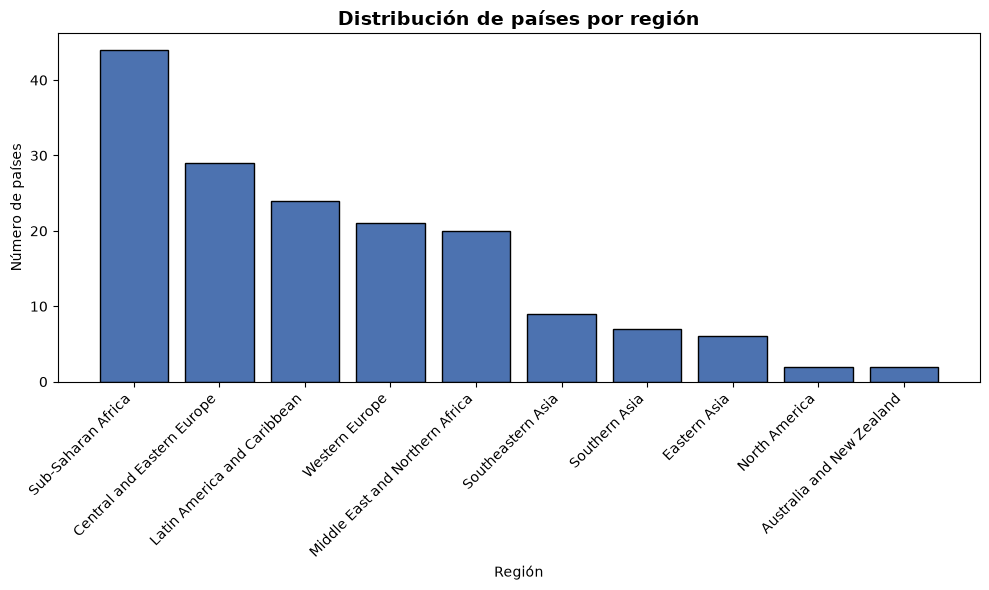

Region
Sub-Saharan Africa                 44
Central and Eastern Europe         29
Latin America and Caribbean        24
Western Europe                     21
Middle East and Northern Africa    20
Southeastern Asia                   9
Southern Asia                       7
Eastern Asia                        6
North America                       2
Australia and New Zealand           2
Name: count, dtype: int64

In [108]:
region_counts = df.drop_duplicates('Country')['Region'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(region_counts.index, region_counts.values, color='#4C72B0', edgecolor='black')
ax.set_title('Distribución de países por región', fontsize=14, fontweight='bold')
ax.set_xlabel('Región')
ax.set_ylabel('Número de países')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

region_counts

**Interpretación:** tenemos países únicos por región para que los 5 años de cada país no influyan en el conteo. Sub-Saharan Africa tiene 44 países, luego Central and Eastern Europe y Latin America and Caribbean. En el otro extremo, North America y Australia and New Zealand solo tienen 2 países cada una. La distribución está lejos de ser uniforme entre regiones.

#### 17. Gráfico de pie — Proporción de países por región

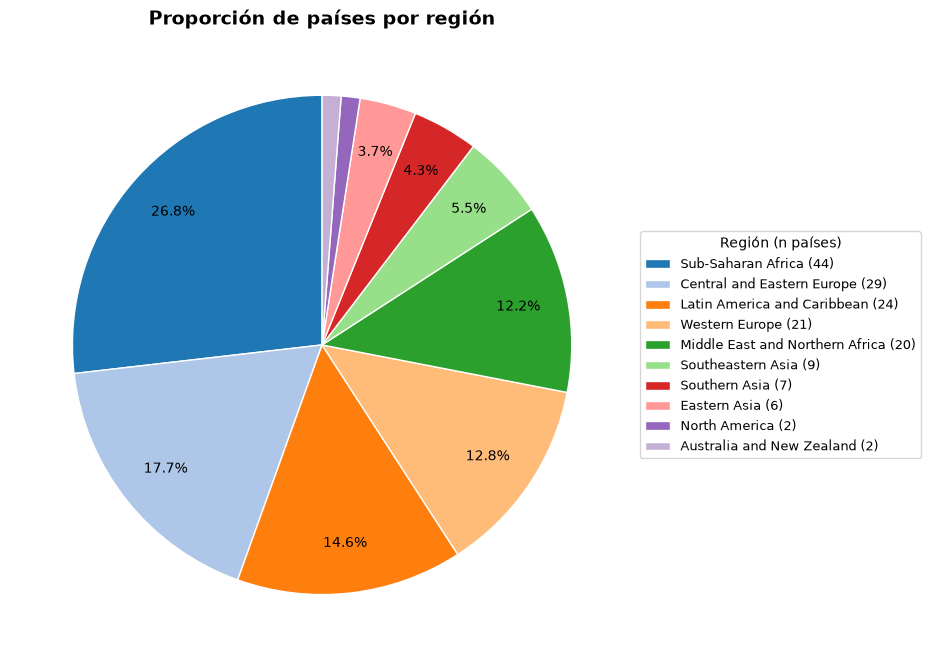

In [109]:
def autopct_fmt(pct):
    return f'{pct:.1f}%' if pct > 3 else ''

fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.cm.tab20.colors
wedges, texts, autotexts = ax.pie(
    region_counts.values,
    autopct=autopct_fmt,
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('Proporción de países por región', fontsize=14, fontweight='bold')
ax.legend(wedges, [f'{r} ({c})' for r, c in zip(region_counts.index, region_counts.values)],
          title='Región (n países)', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

**Interpretación:** en proporción, Sub-Saharan Africa representa 26.8% de los países del estudio, y junto con Central and Eastern Europe  y Latin America and Caribbean suman cerca del 59% de la muestra completa. North America y Australia and New Zealand combinadas apenas llegan a 2.4%.

#### 18. Histograma — Distribución del Happiness Score

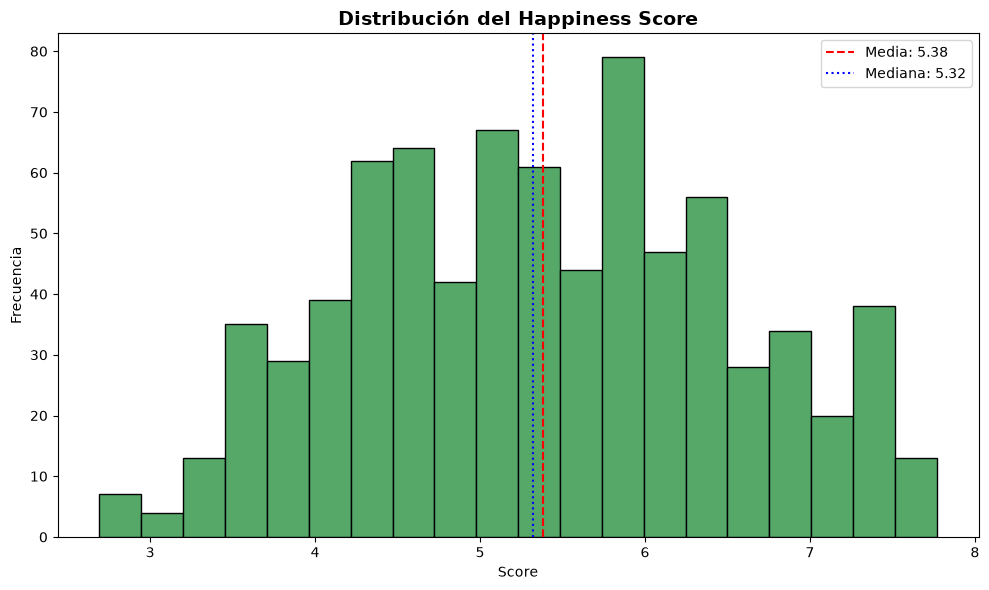

Skewness (asimetría): 0.035859433273691114


In [110]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['Score'], bins=20, color='#55A868', edgecolor='black')
ax.axvline(df['Score'].mean(), color='red', linestyle='--', label=f"Media: {df['Score'].mean():.2f}")
ax.axvline(df['Score'].median(), color='blue', linestyle=':', label=f"Mediana: {df['Score'].median():.2f}")
ax.set_title('Distribución del Happiness Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

print('Skewness (asimetría):', df['Score'].skew())

**Interpretación:** el skewness es de apenas ≈0.036, prácticamente 0, y la media (5.38) y la mediana (5.32) quedan casi encima una de la otra en el histograma. Esto confirma que la distribución es **simétrica** (no sesgada), con forma aproximadamente acampanada

#### 19. Scatter plot — Relación entre GDP per Capita y Score

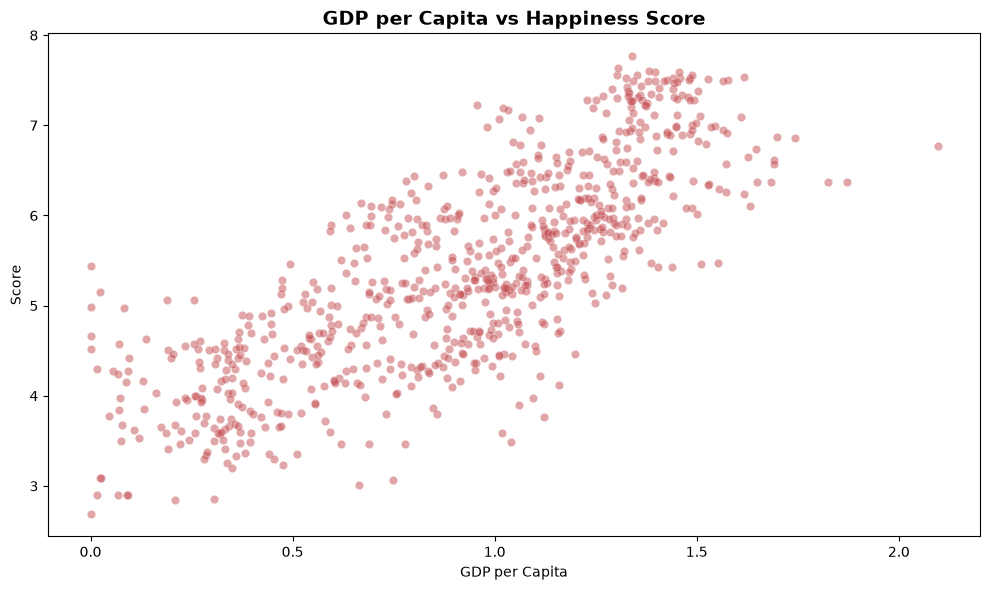

Correlación de Pearson: 0.789


In [111]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['GDP per Capita'], df['Score'], alpha=0.5, color='#C44E52', edgecolor='white', linewidth=0.3)
ax.set_title('GDP per Capita vs Happiness Score', fontsize=14, fontweight='bold')
ax.set_xlabel('GDP per Capita')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

correlacion = df['GDP per Capita'].corr(df['Score'])
print(f'Correlación de Pearson: {correlacion:.3f}')

**Interpretación:** la correlación de Pearson es de ≈0.79, una correlación **positiva fuerte**: a mayor GDP per Capita, mayor Score de felicidad. La nube de puntos sigue una tendencia ascendente clara.

#### 20. Boxplot — Perceptions of corruption

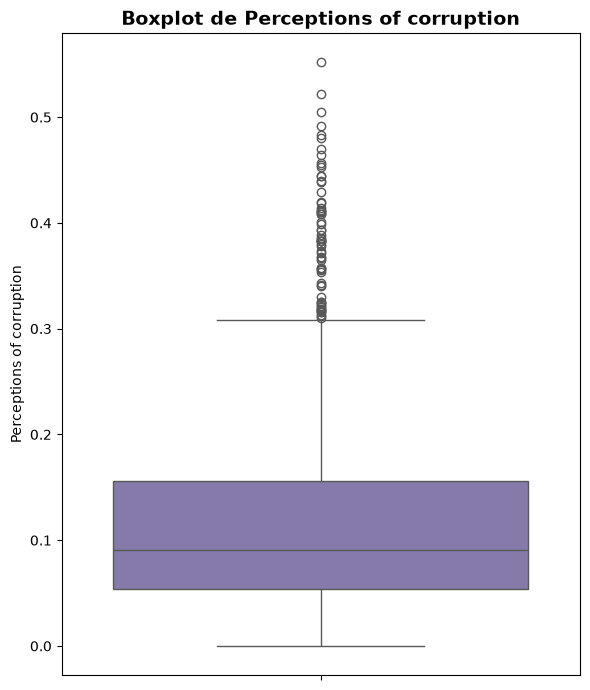

Número de outliers (por encima del límite superior): 67
Porcentaje del dataset: 8.6 %

Países que aparecen como outlier en los 5 años:
Country
Switzerland    5
Denmark        5
Norway         5
Finland        5
Sweden         5
New Zealand    5
Luxembourg     5
Singapore      5
Rwanda         5
Name: count, dtype: int64


In [112]:
fig, ax = plt.subplots(figsize=(6, 7))
sns.boxplot(y=df['Perceptions of corruption'], ax=ax, color='#8172B2')
ax.set_title('Boxplot de Perceptions of corruption', fontsize=14, fontweight='bold')
ax.set_ylabel('Perceptions of corruption')
plt.tight_layout()
plt.show()

upper_bound = 0.309
outliers = df[df['Perceptions of corruption'] > upper_bound]
print('Número de outliers (por encima del límite superior):', len(outliers))
print('Porcentaje del dataset:', round(len(outliers) / len(df) * 100, 1), '%')
print()
print('Países que aparecen como outlier en los 5 años:')
print(outliers['Country'].value_counts().loc[lambda s: s == 5])

**Interpretación:** el boxplot confirma visualmente lo encontrado en el análisis manual de cuartiles del numeral 10 (Q1=0.054, Q3=0.156, IQR=0.102, upper_bound=0.309): la caja queda concentrada en valores bajos y hay una cola larga hacia la derecha, con 67 registros (8.6% del dataset) por encima del límite superior. No hay outliers por debajo del límite inferior porque la variable está acotada en 0. Es clave aclarar qué significan estos outliers: `Perceptions of corruption` alto = la ciudadanía percibe **baja** corrupción / **alta** confianza institucional, así que no son datos "malos" sino países con gobiernos excepcionalmente confiables — de hecho Suiza, Dinamarca, Noruega, Finlandia, Suecia, Nueva Zelanda, Luxemburgo, Singapur y Ruanda aparecen como outlier en los 5 años del dataset, es decir, es un comportamiento sostenido y no ruido puntual.

#### 21. Gráfico de líneas — Evolución del Score promedio (2015–2019)

El dataset **sí tiene una variable temporal** (`year`).

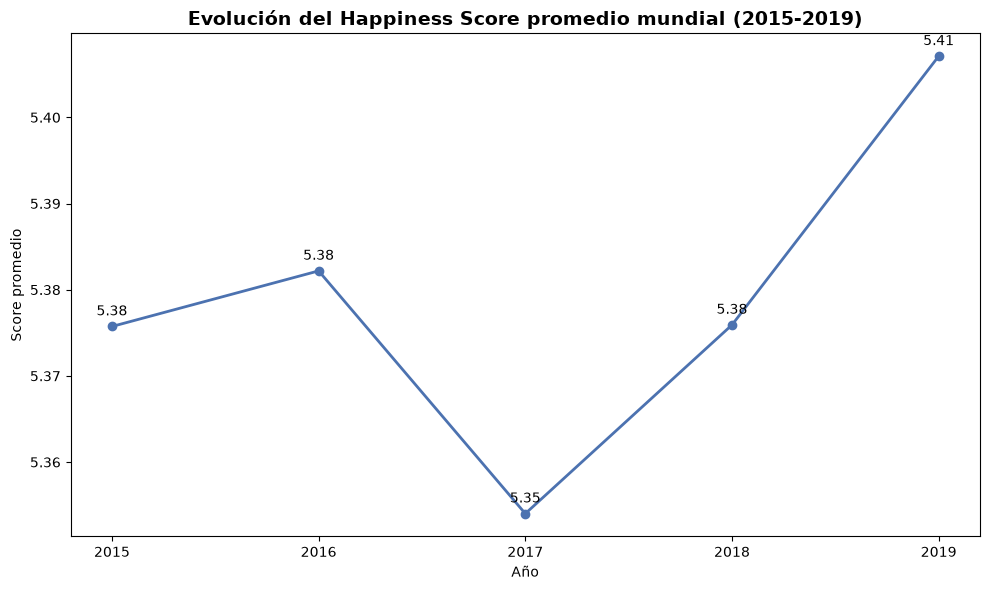

year
2015    5.375734
2016    5.382185
2017    5.354019
2018    5.375917
2019    5.407096
Name: Score, dtype: float64

In [113]:
score_por_anio = df.groupby('year')['Score'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(score_por_anio.index, score_por_anio.values, marker='o', linewidth=2, color='#4C72B0')
for x, y in zip(score_por_anio.index, score_por_anio.values):
    ax.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
ax.set_title('Evolución del Happiness Score promedio mundial (2015-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Score promedio')
ax.set_xticks(score_por_anio.index)
plt.tight_layout()
plt.show()

score_por_anio

**Interpretación:** la línea se mantiene casi plana entre 5.35 y 5.41 a lo largo de los 5 años, con una leve caída en 2017 (5.354) y una recuperación hasta el máximo del período en 2019 (5.407). El cambio neto 2015→2019 es de apenas +0.55%, consistente con lo ya calculado en la fase de preguntas de negocio. Esto confirma que, a nivel mundial, la felicidad promedio fue notablemente **estable** durante el período, sin una tendencia sostenida al alza ni a la baja; la caída puntual de 2017 vale la pena marcarla como una alerta a revisar

### Conclusiones

- Este dataset nos permitio identificar la importancia de ese primer analisis, sobre todo en este caso cuando tratamos de tener un analisis temporal de datasets que no estan estandarizados, puesto que nos lleva a preguntarnos su relevancia, como normalizarlos y si en ese proceso estamos eliminando datos o agregando.

- Por un analis social, identificamos que el nivel de felicidad de un país esta dado por multiples factores y que esta relacionado directamente con los aspectos básicos de vida y de la gestión de un gobierno

- En esta exploración de los datos identificamos que las variables que más influyen son: `Social Support, Perceptions of corruption, GDP per capital, Generosity, Freedom, Health (Life Expectancy)`

- Una consideración sería revisar cuales variables no son necesarias en el entrenamiento como podrian serlo: `Country, Overall rank, year`

Los gráficos permitieron **validar patrones ocultos en los datos y comunicar de forma intuitiva** que la felicidad mundial es multifactorial y geográficamente desigual: mientras países con mayor GDP tienden a ser más felices (correlación 0.79), la estabilidad global en los últimos 5 años sugiere que otros factores como gobernanza y soporte social son igualmente determinantes.